In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore') 

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

In [3]:
train_data_path = "D:\python-venv\CNN\data\seg_train\seg_train"
test_data_path =  "D:\python-venv\CNN\data\seg_test\seg_test"

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
datagen = ImageDataGenerator(rescale = 1/255)

In [6]:
train_datagen = datagen.flow_from_directory(train_data_path,target_size=(64,64),batch_size=25,class_mode='input')
test_datagen = datagen.flow_from_directory(test_data_path,target_size=(64,64),batch_size=25,class_mode='input')

Found 14034 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [7]:
batch1 = next(train_datagen)

In [8]:
type(batch1)

tuple

In [9]:
len(batch1)

2

In [10]:
batch1[0].shape

(25, 64, 64, 3)

In [11]:
14034/25

561.36

In [12]:
batch1[1].shape

(25, 64, 64, 3)

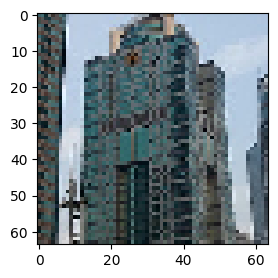

In [13]:
plt.figure(figsize=(3,3))
plt.imshow(batch1[0][2])
plt.show()

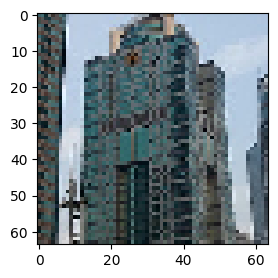

In [14]:
plt.figure(figsize=(3,3))
plt.imshow(batch1[1][2])
plt.show()

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D,Conv2DTranspose, Dropout, BatchNormalization,UpSampling2D

In [16]:
from keras_cv.layers import Grayscale

ERROR:absl:cannot import name 'runtime_version' from 'google.protobuf' (d:\python-venv\keras2\lib\site-packages\google\protobuf\__init__.py)
Traceback (most recent call last):
  File "d:\python-venv\keras2\lib\site-packages\tensorflow_datasets\__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
  File "d:\python-venv\keras2\lib\site-packages\tensorflow_datasets\rlds\__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "d:\python-venv\keras2\lib\site-packages\tensorflow_datasets\rlds\envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "d:\python-venv\keras2\lib\site-packages\tensorflow_datasets\core\__init__.py", line 21, in <module>
    from tensorflow_datasets.core import community
  File "d:\python-venv\keras2\lib\site-packages\tensorflow_datasets\core\community\__init__.py", line 19, in <module>
    from ten

In [17]:
gray_scale_layer = Grayscale()

In [18]:
gray = gray_scale_layer(batch1[0][0:5])

In [19]:
gray.shape

TensorShape([5, 64, 64, 1])

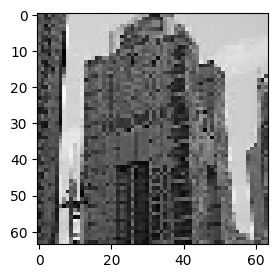

In [20]:
plt.figure(figsize=(3,3))
plt.imshow(gray[2],cmap='gray')
plt.show()

In [21]:
encoder = Sequential()
encoder.add(Conv2D(64,kernel_size=(3,3),strides=(1,1),padding='same',input_shape=(64,64,1)))
encoder.add(MaxPool2D())
encoder.add(Conv2D(128,kernel_size=(3,3),strides=(1,1),padding='same'))
encoder.add(MaxPool2D())
encoder.add(Conv2D(256,kernel_size=(3,3),strides=(1,1),padding='same'))
encoder.add(MaxPool2D())
encoder.add(Conv2D(512,kernel_size=(3,3),strides=(1,1),padding='same'))


decoder = Sequential()
decoder.add(Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same', activation='relu'))
decoder.add(Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same', activation='relu'))
decoder.add(Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', activation='relu'))
decoder.add(BatchNormalization())
decoder.add(Conv2DTranspose(3, (1, 1), strides=(1, 1), padding='same', activation='sigmoid'))

autoencoder = Sequential()
autoencoder.add(Grayscale(input_shape=(64,64,3)))
autoencoder.add(encoder)
autoencoder.add(decoder)

In [22]:
encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,549,824 (5.91 MB)

 Trainable params: 1,549,824 (5.91 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (None, 16, 16, 256)    │       524,544 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       131,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │        32,832 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │           195 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 689,027 (2.63 MB)

 Trainable params: 688,899 (2.63 MB)

 Non-trainable params: 128 (512.00 B)

In [24]:
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ grayscale_1 (Grayscale)         │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 8, 8, 512)      │     1,549,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 64, 64, 3)      │       689,027 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,238,851 (8.54 MB)

 Trainable params: 2,238,723 (8.54 MB)

 Non-trainable params: 128 (512.00 B)

In [25]:
opt = tf.keras.optimizers.Adam(0.001)
loss = tf.keras.losses.MeanAbsoluteError()
autoencoder.compile(optimizer=opt,loss=loss)

In [26]:
autoencoder.fit(train_datagen,validation_data=(test_datagen),steps_per_epoch=561,epochs=50,verbose=2)

Epoch 1/50
561/561 - 539s - 962ms/step - loss: 0.1068 - val_loss: 0.1049
Epoch 2/50
561/561 - 19s - 35ms/step - loss: 0.1002 - val_loss: 0.0978
Epoch 3/50
561/561 - 309s - 551ms/step - loss: 0.0927 - val_loss: 0.0857
Epoch 4/50
561/561 - 19s - 33ms/step - loss: 0.0830 - val_loss: 0.0854
Epoch 5/50
561/561 - 300s - 535ms/step - loss: 0.0877 - val_loss: 0.0834
Epoch 6/50
561/561 - 18s - 33ms/step - loss: 0.0787 - val_loss: 0.0834
Epoch 7/50
561/561 - 293s - 522ms/step - loss: 0.0838 - val_loss: 0.0830
Epoch 8/50
561/561 - 18s - 32ms/step - loss: 0.0928 - val_loss: 0.0861
Epoch 9/50
561/561 - 300s - 534ms/step - loss: 0.0818 - val_loss: 0.0788
Epoch 10/50
561/561 - 22s - 40ms/step - loss: 0.0755 - val_loss: 0.0782
Epoch 11/50
561/561 - 339s - 604ms/step - loss: 0.0803 - val_loss: 0.0770
Epoch 12/50
561/561 - 24s - 42ms/step - loss: 0.0953 - val_loss: 0.0769
Epoch 13/50
561/561 - 370s - 659ms/step - loss: 0.0795 - val_loss: 0.0775
Epoch 14/50
561/561 - 23s - 41ms/step - loss: 0.0880 - val_

In [31]:
from glob import glob
import cv2

In [32]:
img_path = glob("D:\python-venv\CNN\data\seg_test\seg_test/*/*.jpg")
img_path = img_path[:200]

color_img = []
gray_img = []

for path in img_path:
  img_bgr = cv2.resize(cv2.imread(path),(64,64))
  # convert bgr to rgb
  img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  color_img.append(img)

  img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
  gray_img.append(img)



color_img = np.array(color_img) / 255
gray_img = np.array(gray_img) / 255



In [33]:
pred_img = decoder.predict(encoder.predict(gray_img))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


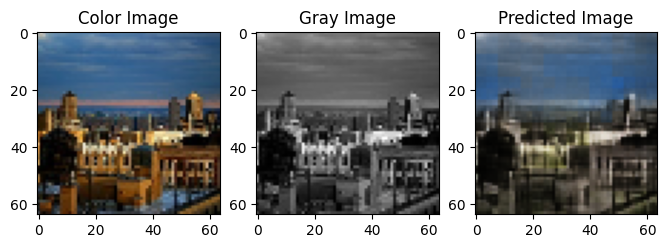

In [34]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 3, 1)
plt.imshow(color_img[10])
plt.title('Color Image')

plt.subplot(1, 3, 2)
plt.imshow(gray_img[10], cmap='gray')
plt.title('Gray Image')

plt.subplot(1, 3, 3)
plt.imshow(pred_img[10])
plt.title('Predicted Image')

plt.show()